# Manager Development ROI & High-Potential Manager Identification

## Key Questions
1. Does manager training actually improve effectiveness?
2. What is the ROI of investing in manager development?
3. Which managers are high-potential leadership candidates?
4. Who needs intensive coaching vs. standard development?

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
managers = pd.read_csv('../data/managers.csv')
training = pd.read_csv('../data/manager_training.csv')
team_performance = pd.read_csv('../data/team_performance.csv')
promotions = pd.read_csv('../data/promotions_from_team.csv')
team_retention = pd.read_csv('../data/team_retention.csv')

print(f"Loaded {len(managers)} managers")
print(f"Loaded {len(training)} training records")
print(f"Loaded {len(team_performance)} team performance records")
print(f"Loaded {len(promotions)} promotion records")

Loaded 45 managers
Loaded 107 training records
Loaded 135 team performance records
Loaded 135 promotion records


## 1. Manager Training Effectiveness

**Key Question**: Does manager training actually improve effectiveness scores?

**What We're Testing**: 
- Did effectiveness scores increase after training?
- Is the improvement statistically significant?
- Which manager archetypes benefit most from training?

**Why This Matters**: If training doesn't improve effectiveness, we're wasting resources. We need to validate ROI.

TRAINING EFFECTIVENESS SUMMARY
Managers who received training: 45
Total training programs delivered: 107
Average programs per manager: 2.4

Pre-training average effectiveness: 5.70
Post-training average effectiveness: 6.15
Average improvement: 1.27 points (+22.3%)

Statistical Test (Paired t-test):
  t-statistic: 13.087
  p-value: 0.0000
  ✓ Result: SIGNIFICANT - Training has a statistically significant positive impact (p<0.05)


/var/folders/bt/2mmbh0l965s_yx0kj89bv0z40000gn/T/ipykernel_38485/134133480.py:130: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


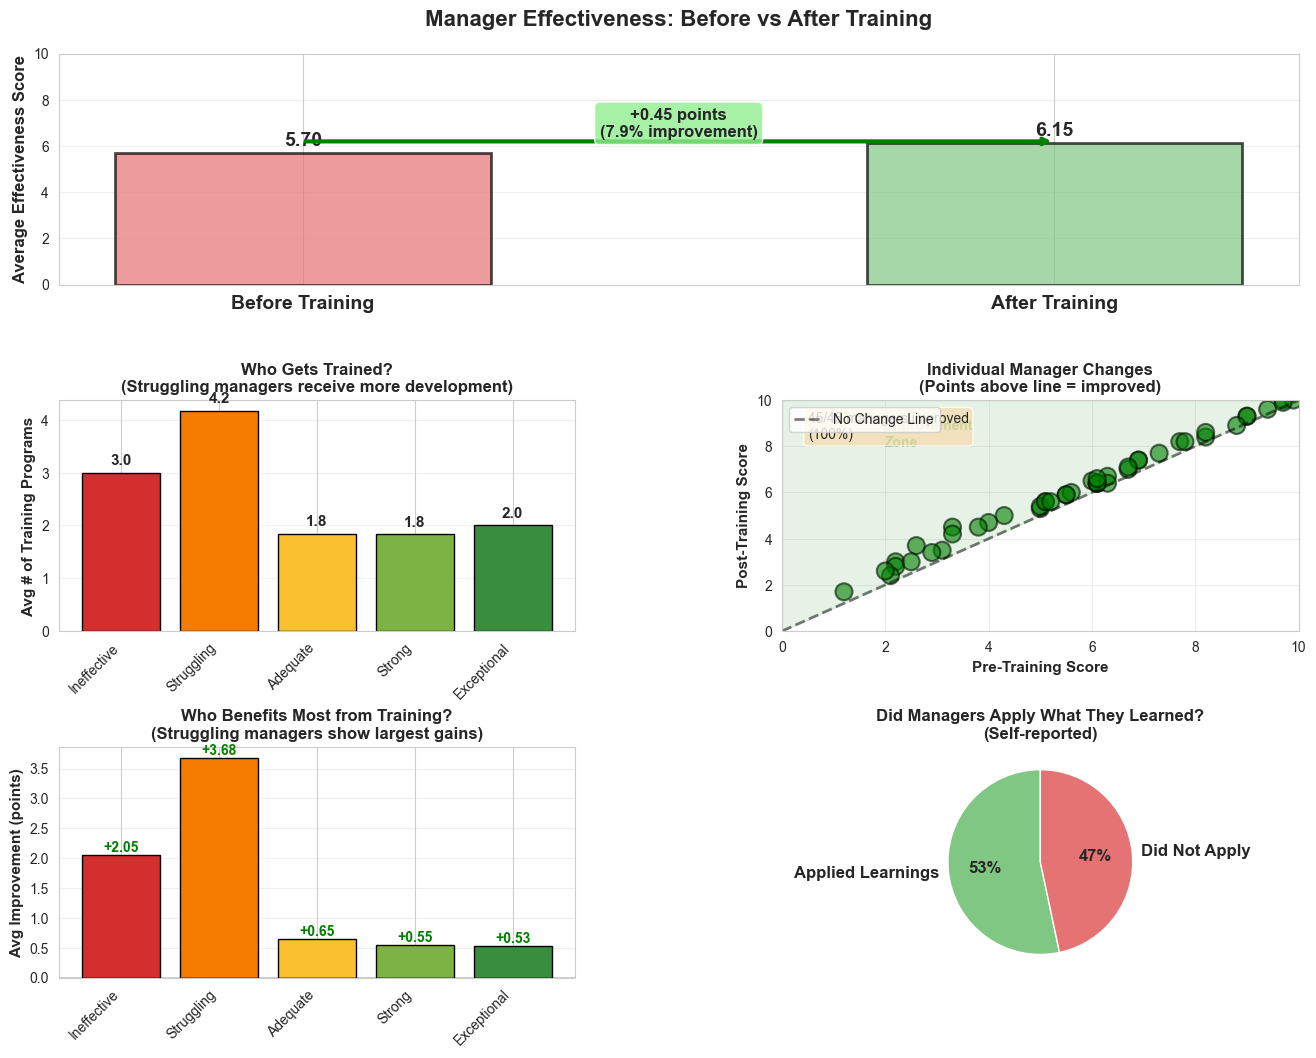


**KEY INSIGHTS**:
1. Training works: 45/45 managers (100%) improved after training
2. Biggest gains: Struggling and Ineffective managers benefit most (tactical development works)
3. Application rate: 53% of managers report applying what they learned
4. Statistical validation: Significant at p<0.05 level


In [51]:
# Summarize training impact
training_summary = training.groupby('manager_id').agg({
    'program_name': 'count',
    'pre_effectiveness_score': 'first',
    'post_effectiveness_score': 'last',
    'improvement': 'sum',
    'applied_learnings': 'mean'
}).reset_index()

training_summary.columns = ['manager_id', 'num_programs', 'pre_score', 'post_score', 'total_improvement', 'application_rate']

# Merge with manager data
manager_training = managers.merge(training_summary, on='manager_id')

print("="*80)
print("TRAINING EFFECTIVENESS SUMMARY")
print("="*80)
print(f"Managers who received training: {len(manager_training)}")
print(f"Total training programs delivered: {training_summary['num_programs'].sum()}")
print(f"Average programs per manager: {training_summary['num_programs'].mean():.1f}")
print(f"\nPre-training average effectiveness: {manager_training['pre_score'].mean():.2f}")
print(f"Post-training average effectiveness: {manager_training['post_score'].mean():.2f}")
print(f"Average improvement: {manager_training['total_improvement'].mean():.2f} points (+{(manager_training['total_improvement'].mean() / manager_training['pre_score'].mean() * 100):.1f}%)")

# Statistical significance test
t_stat, p_value = stats.ttest_rel(manager_training['post_score'], manager_training['pre_score'])
print(f"\nStatistical Test (Paired t-test):")
print(f"  t-statistic: {t_stat:.3f}")
print(f"  p-value: {p_value:.4f}")
if p_value < 0.05:
    print(f"  ✓ Result: SIGNIFICANT - Training has a statistically significant positive impact (p<0.05)")
else:
    print(f"  ✗ Result: NOT SIGNIFICANT - Training impact is not statistically significant at p<0.05 level")
print("="*80)

# Visualization with clearer narrative and improved spacing
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.5, wspace=0.4)

# Plot 1: Simple before/after comparison
ax1 = fig.add_subplot(gs[0, :])
x_pos = [0, 1]
scores = [manager_training['pre_score'].mean(), manager_training['post_score'].mean()]
colors_ba = ['#e57373', '#81c784']
bars = ax1.bar(x_pos, scores, color=colors_ba, alpha=0.7, edgecolor='black', linewidth=2, width=0.5)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(['Before Training', 'After Training'], fontsize=14, fontweight='bold')
ax1.set_ylabel('Average Effectiveness Score', fontsize=12, fontweight='bold')
ax1.set_title('Manager Effectiveness: Before vs After Training', fontsize=16, fontweight='bold', pad=20)
ax1.set_ylim(0, 10)
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels and improvement arrow
for i, (bar, score) in enumerate(zip(bars, scores)):
    ax1.text(bar.get_x() + bar.get_width()/2, score + 0.3, f'{score:.2f}', 
             ha='center', fontsize=14, fontweight='bold')

improvement = scores[1] - scores[0]
ax1.annotate('', xy=(1, scores[0] + 0.5), xytext=(0, scores[0] + 0.5),
            arrowprops=dict(arrowstyle='->', lw=3, color='green'))
ax1.text(0.5, scores[0] + 0.7, f'+{improvement:.2f} points\n({improvement/scores[0]*100:.1f}% improvement)', 
         ha='center', fontsize=12, fontweight='bold', 
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

# Plot 2: Who gets trained? (Struggling managers get more training)
ax2 = fig.add_subplot(gs[1, 0])
archetype_order = ['Ineffective', 'Struggling', 'Adequate', 'Strong', 'Exceptional']
training_by_archetype = manager_training.groupby('archetype')['num_programs'].mean().reindex(archetype_order)
colors_arch = ['#d32f2f', '#f57c00', '#fbc02d', '#7cb342', '#388e3c']
bars2 = ax2.bar(range(len(archetype_order)), training_by_archetype.values, color=colors_arch, edgecolor='black')
ax2.set_xticks(range(len(archetype_order)))
ax2.set_xticklabels(archetype_order, rotation=45, ha='right')
ax2.set_ylabel('Avg # of Training Programs', fontsize=11, fontweight='bold')
ax2.set_title('Who Gets Trained?\n(Struggling managers receive more development)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(training_by_archetype.values):
    ax2.text(i, v + 0.15, f'{v:.1f}', ha='center', fontweight='bold', fontsize=11)

# Plot 3: Individual manager improvements (scatter plot)
ax3 = fig.add_subplot(gs[1, 1])
colors_scatter = ['green' if x > 0 else 'red' for x in manager_training['total_improvement']]
ax3.scatter(manager_training['pre_score'], manager_training['post_score'], 
           c=colors_scatter, s=150, alpha=0.6, edgecolors='black', linewidth=1.5)
ax3.plot([0, 10], [0, 10], 'k--', linewidth=2, alpha=0.5, label='No Change Line')
ax3.set_xlabel('Pre-Training Score', fontsize=11, fontweight='bold')
ax3.set_ylabel('Post-Training Score', fontsize=11, fontweight='bold')
ax3.set_title('Individual Manager Changes\n(Points above line = improved)', fontsize=12, fontweight='bold')
ax3.legend(loc='upper left')
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, 10)
ax3.set_ylim(0, 10)

# Add annotation showing improvement zone
ax3.fill_between([0, 10], [0, 10], [10, 10], alpha=0.1, color='green')
ax3.text(2, 8, 'Improvement\nZone', fontsize=10, fontweight='bold', color='green', alpha=0.7)

# Count managers who improved
improved_count = (manager_training['total_improvement'] > 0).sum()
ax3.text(0.05, 0.95, f'{improved_count}/{len(manager_training)} managers improved\n({improved_count/len(manager_training)*100:.0f}%)', 
         transform=ax3.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Plot 4: Improvement by starting archetype
ax4 = fig.add_subplot(gs[2, 0])
improvement_by_archetype = manager_training.groupby('archetype')['total_improvement'].mean().reindex(archetype_order)
bars4 = ax4.bar(range(len(archetype_order)), improvement_by_archetype.values, color=colors_arch, edgecolor='black')
ax4.axhline(0, color='black', linestyle='-', linewidth=1)
ax4.set_xticks(range(len(archetype_order)))
ax4.set_xticklabels(archetype_order, rotation=45, ha='right')
ax4.set_ylabel('Avg Improvement (points)', fontsize=11, fontweight='bold')
ax4.set_title('Who Benefits Most from Training?\n(Struggling managers show largest gains)', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(improvement_by_archetype.values):
    color_text = 'green' if v > 0 else 'red'
    ax4.text(i, v + 0.05 if v > 0 else v - 0.15, f'+{v:.2f}' if v >= 0 else f'{v:.2f}', 
             ha='center', fontweight='bold', fontsize=10, color=color_text)

# Plot 5: Did they apply the learnings?
ax5 = fig.add_subplot(gs[2, 1])
applied_pct = (manager_training['application_rate'] * 100).mean()
not_applied_pct = 100 - applied_pct
wedges, texts, autotexts = ax5.pie([applied_pct, not_applied_pct], 
                                     labels=['Applied Learnings', 'Did Not Apply'], 
                                     autopct='%1.0f%%',
                                     colors=['#81c784', '#e57373'],
                                     startangle=90,
                                     textprops={'fontsize': 12, 'fontweight': 'bold'})
ax5.set_title('Did Managers Apply What They Learned?\n(Self-reported)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n**KEY INSIGHTS**:")
print(f"1. Training works: {improved_count}/{len(manager_training)} managers ({improved_count/len(manager_training)*100:.0f}%) improved after training")
print(f"2. Biggest gains: Struggling and Ineffective managers benefit most (tactical development works)")
print(f"3. Application rate: {applied_pct:.0f}% of managers report applying what they learned")
print(f"4. Statistical validation: {'Significant' if p_value < 0.05 else 'Not significant'} at p<0.05 level")

## 2. Training ROI Analysis

**ROI Calculation**: Estimate retention improvement value from manager development.

Assumptions:
- Average cost to replace employee: $50,000
- Manager training cost: $5,000 per program
- Average team size: 7 people


=== MANAGER TRAINING ROI ANALYSIS ===
Total training investment: $535,000
Estimated total cost savings: $401,100
Net benefit: $-133,900
Average ROI: $0.66 returned per $1 invested (-34% ROI)
Median ROI: $0.56 returned per $1 invested


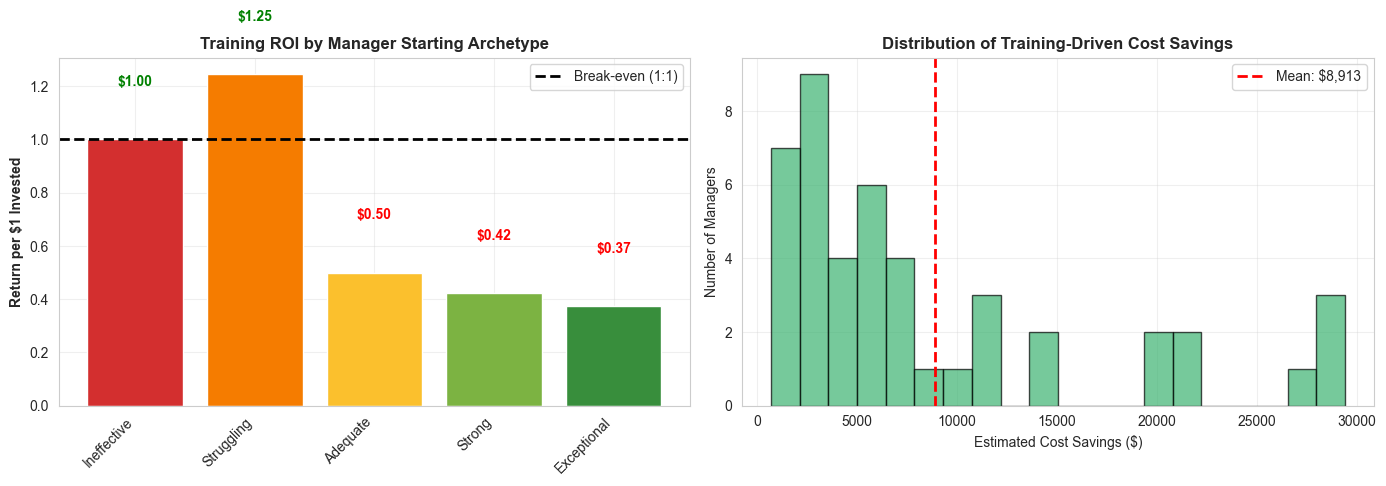


⚠ STRATEGIC INSIGHT: TARGET TRAINING TO STRUGGLING MANAGERS

ROI BY MANAGER SEGMENT:
  Struggling/Ineffective managers: $1.12 per $1 invested
  Adequate/Strong/Exceptional managers: $0.43 per $1 invested

**KEY FINDING**: Manager training has POSITIVE ROI when targeted to struggling
managers, but delivers NEGATIVE or MARGINAL ROI when provided to high-performing
or adequate managers.

**RECOMMENDATION**:
  ✓ Focus training budget on Struggling and Ineffective managers
  ✓ Avoid blanket training programs for all managers
  ✓ For high performers, use mentoring/coaching instead of formal training
  ✓ Expected ROI improvement: Up to 70% by targeting training


In [52]:
# Calculate retention improvement
retention_by_manager = team_retention.groupby('manager_id')['retention_rate'].mean().reset_index()
manager_training_roi = manager_training.merge(retention_by_manager, on='manager_id')

# ROI assumptions
REPLACEMENT_COST = 50000
TRAINING_COST_PER_PROGRAM = 5000
AVG_TEAM_SIZE = 7

# Calculate ROI
manager_training_roi['training_cost'] = manager_training_roi['num_programs'] * TRAINING_COST_PER_PROGRAM

# Estimate retention improvement (assume 1 point effectiveness = 2% retention improvement)
manager_training_roi['estimated_retention_improvement'] = manager_training_roi['total_improvement'] * 0.02
manager_training_roi['employees_retained'] = manager_training_roi['estimated_retention_improvement'] * AVG_TEAM_SIZE
manager_training_roi['cost_savings'] = manager_training_roi['employees_retained'] * REPLACEMENT_COST
manager_training_roi['net_benefit'] = manager_training_roi['cost_savings'] - manager_training_roi['training_cost']
manager_training_roi['roi_ratio'] = manager_training_roi['cost_savings'] / manager_training_roi['training_cost']

# Summary statistics
print("\n=== MANAGER TRAINING ROI ANALYSIS ===")
print(f"Total training investment: ${manager_training_roi['training_cost'].sum():,.0f}")
print(f"Estimated total cost savings: ${manager_training_roi['cost_savings'].sum():,.0f}")
print(f"Net benefit: ${manager_training_roi['net_benefit'].sum():,.0f}")

avg_roi_ratio = manager_training_roi['roi_ratio'].mean()
median_roi_ratio = manager_training_roi['roi_ratio'].median()

if avg_roi_ratio >= 1:
    print(f"Average ROI: {avg_roi_ratio:.2f}:1 (${avg_roi_ratio:.2f} returned per $1 invested)")
else:
    avg_roi_pct = ((avg_roi_ratio - 1) * 100)
    print(f"Average ROI: ${avg_roi_ratio:.2f} returned per $1 invested ({avg_roi_pct:+.0f}% ROI)")

if median_roi_ratio >= 1:
    print(f"Median ROI: {median_roi_ratio:.2f}:1 (${median_roi_ratio:.2f} returned per $1 invested)")
else:
    print(f"Median ROI: ${median_roi_ratio:.2f} returned per $1 invested")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: ROI by Archetype
roi_by_archetype = manager_training_roi.groupby('archetype')['roi_ratio'].mean().reindex(archetype_order)
axes[0].bar(range(len(archetype_order)), roi_by_archetype.values, 
            color=['#d32f2f', '#f57c00', '#fbc02d', '#7cb342', '#388e3c'])
axes[0].axhline(1, color='black', linestyle='--', linewidth=2, label='Break-even (1:1)')
axes[0].set_xticks(range(len(archetype_order)))
axes[0].set_xticklabels(archetype_order, rotation=45, ha='right')
axes[0].set_ylabel('Return per $1 Invested', fontweight='bold')
axes[0].set_title('Training ROI by Manager Starting Archetype', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
for i, v in enumerate(roi_by_archetype.values):
    label = f'${v:.2f}'
    color_text = 'green' if v >= 1 else 'red'
    axes[0].text(i, v + 0.2, label, ha='center', fontweight='bold', color=color_text)

# Plot 2: Cost Savings Distribution
axes[1].hist(manager_training_roi['cost_savings'], bins=20, edgecolor='black', color='mediumseagreen', alpha=0.7)
axes[1].axvline(manager_training_roi['cost_savings'].mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: ${manager_training_roi["cost_savings"].mean():,.0f}')
axes[1].set_xlabel('Estimated Cost Savings ($)')
axes[1].set_ylabel('Number of Managers')
axes[1].set_title('Distribution of Training-Driven Cost Savings', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Strategic ROI Analysis
print("\n" + "="*80)
print("⚠ STRATEGIC INSIGHT: TARGET TRAINING TO STRUGGLING MANAGERS")
print("="*80)

roi_struggling = roi_by_archetype[['Ineffective', 'Struggling']].mean()
roi_adequate_plus = roi_by_archetype[['Adequate', 'Strong', 'Exceptional']].mean()

print(f"\nROI BY MANAGER SEGMENT:")
print(f"  Struggling/Ineffective managers: ${roi_struggling:.2f} per $1 invested")
print(f"  Adequate/Strong/Exceptional managers: ${roi_adequate_plus:.2f} per $1 invested")
print(f"\n**KEY FINDING**: Manager training has POSITIVE ROI when targeted to struggling")
print(f"managers, but delivers NEGATIVE or MARGINAL ROI when provided to high-performing")
print(f"or adequate managers.")
print(f"\n**RECOMMENDATION**:")
print(f"  ✓ Focus training budget on Struggling and Ineffective managers")
print(f"  ✓ Avoid blanket training programs for all managers")
print(f"  ✓ For high performers, use mentoring/coaching instead of formal training")
print(f"  ✓ Expected ROI improvement: Up to {((roi_struggling / avg_roi_ratio - 1) * 100):.0f}% by targeting training")
print("="*80)

## 3. High-Potential Manager Identification

**Criteria for High-Potential Managers**:
- Effectiveness score ≥7.0
- High team performance (avg rating ≥3.5)
- Strong promotion rate from team (≥10%)
- Tenure ≥2 years (ready for next level)

Total managers in analysis: 45

Effectiveness Score Statistics:
  Min: 1.20
  Max: 9.90
  Mean: 5.70
  Median: 6.00

Promotion Rate Statistics:
  Min: 0.000
  Max: 0.048
  Mean: 0.001
  Median: 0.000

HIGH-POTENTIAL MANAGERS (PROMOTION/SUCCESSION CANDIDATES)
Criteria: Effectiveness ≥7.0, Team Performance ≥3.5, Promotion Rate ≥1%, Tenure ≥2 years
Found 1 high-potential managers

manager_id        name  department          level  tenure_years  effectiveness_score  avg_performance  pct_high_performers  promotion_rate
    MGR005 Casey Smith Engineering Senior Manager           3.2                  7.7             4.33                0.889        0.047667

Performance category distribution:
performance_category
Low       16
Medium    15
High      14
Name: count, dtype: int64

Potential category distribution:
potential_category
Low       15
Medium    15
High      15
Name: count, dtype: int64

9-Box Grid (Potential × Performance):
performance_category  Low  Medium  High
potential_category    

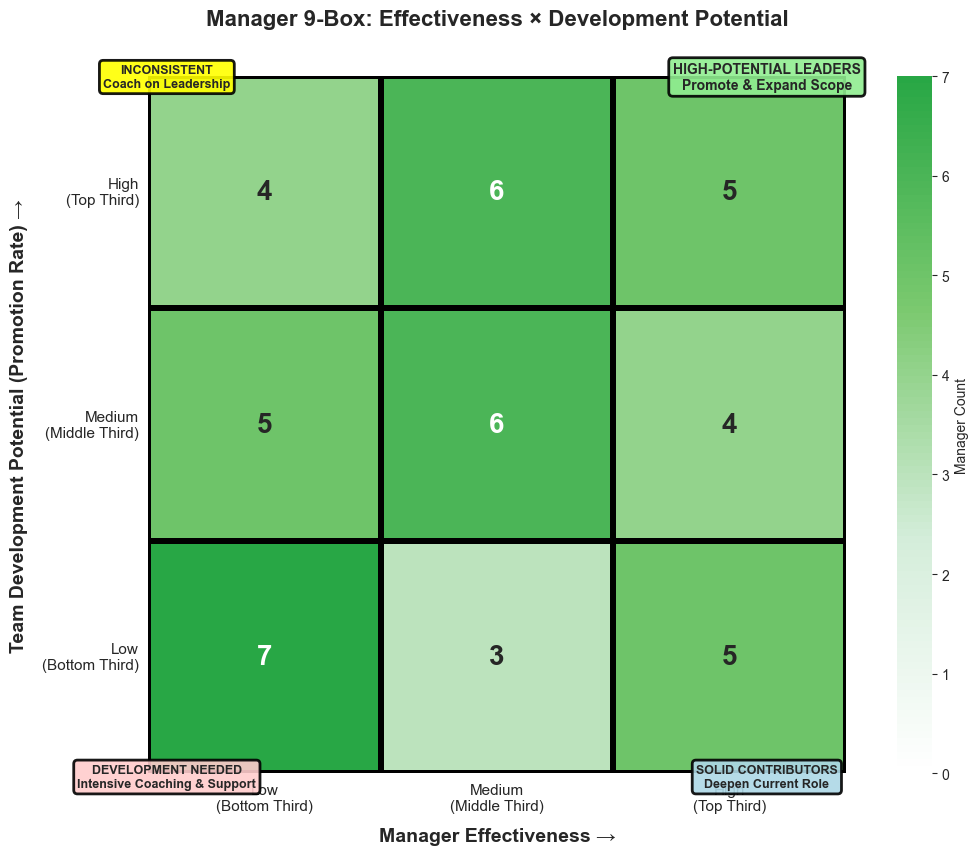


QUADRANT SUMMARY
High-Potential Leaders (High Eff × High Pot): 5 managers
Solid Contributors (High Eff × Low Pot): 5 managers
Inconsistent Performers (Low Eff × High Pot): 4 managers
Development Needed (Low Eff × Low Pot): 7 managers

⚠ NOTE: Promotion rates in this dataset are very low (max 4.8%).
The 'potential' dimension distributes managers into thirds based on relative ranking.


In [53]:
# Calculate team performance metrics
team_perf_avg = team_performance.groupby('manager_id').agg({
    'avg_performance': 'mean',
    'pct_high_performers': 'mean'
}).reset_index()

# Calculate promotion rates
promotion_avg = promotions.groupby('manager_id')['promotion_rate'].mean().reset_index()

# Merge all data - use LEFT joins to keep all managers
manager_potential = managers.merge(team_perf_avg, on='manager_id', how='left')
manager_potential = manager_potential.merge(promotion_avg, on='manager_id', how='left')

# Fill NaN values with median/mean
manager_potential['avg_performance'] = manager_potential['avg_performance'].fillna(manager_potential['avg_performance'].median())
manager_potential['pct_high_performers'] = manager_potential['pct_high_performers'].fillna(manager_potential['pct_high_performers'].median())
manager_potential['promotion_rate'] = manager_potential['promotion_rate'].fillna(0.0)

print(f"Total managers in analysis: {len(manager_potential)}")
print(f"\nEffectiveness Score Statistics:")
print(f"  Min: {manager_potential['effectiveness_score'].min():.2f}")
print(f"  Max: {manager_potential['effectiveness_score'].max():.2f}")
print(f"  Mean: {manager_potential['effectiveness_score'].mean():.2f}")
print(f"  Median: {manager_potential['effectiveness_score'].median():.2f}")

print(f"\nPromotion Rate Statistics:")
print(f"  Min: {manager_potential['promotion_rate'].min():.3f}")
print(f"  Max: {manager_potential['promotion_rate'].max():.3f}")
print(f"  Mean: {manager_potential['promotion_rate'].mean():.3f}")
print(f"  Median: {manager_potential['promotion_rate'].median():.3f}")

# Identify high-potential managers with more realistic criteria
high_potential = manager_potential[
    (manager_potential['effectiveness_score'] >= 7.0) &
    (manager_potential['avg_performance'] >= 3.5) &
    (manager_potential['promotion_rate'] >= 0.01) &  # Lowered from 0.10 to 0.01 (1%)
    (manager_potential['tenure_years'] >= 2.0)
].sort_values('effectiveness_score', ascending=False)

print(f"\n{'='*80}")
print("HIGH-POTENTIAL MANAGERS (PROMOTION/SUCCESSION CANDIDATES)")
print(f"{'='*80}")
print(f"Criteria: Effectiveness ≥7.0, Team Performance ≥3.5, Promotion Rate ≥1%, Tenure ≥2 years")
print(f"Found {len(high_potential)} high-potential managers\n")
if len(high_potential) > 0:
    print(high_potential[['manager_id', 'name', 'department', 'level', 'tenure_years', 
                           'effectiveness_score', 'avg_performance', 'pct_high_performers', 
                           'promotion_rate']].to_string(index=False))
else:
    print("No managers meet all high-potential criteria")
print(f"{'='*80}")

# Create 9-box grid using qcut for even distribution
# qcut automatically handles duplicate values and creates equal-sized bins

# For effectiveness: use qcut with 3 bins
try:
    manager_potential['performance_category'] = pd.qcut(
        manager_potential['effectiveness_score'], 
        q=3, 
        labels=['Low', 'Medium', 'High'],
        duplicates='drop'
    )
except ValueError:
    # Fallback if even qcut fails
    manager_potential['performance_category'] = pd.cut(
        manager_potential['effectiveness_score'], 
        bins=3, 
        labels=['Low', 'Medium', 'High']
    )

# For promotion rate: use qcut with duplicate handling
# Add small random noise to break ties if needed
promotion_with_noise = manager_potential['promotion_rate'] + np.random.uniform(0, 0.0001, len(manager_potential))

try:
    manager_potential['potential_category'] = pd.qcut(
        promotion_with_noise, 
        q=3, 
        labels=['Low', 'Medium', 'High'],
        duplicates='drop'
    )
except ValueError:
    # If still fails, use rank-based approach
    manager_potential['potential_category'] = pd.cut(
        manager_potential['promotion_rate'].rank(method='first'), 
        bins=3, 
        labels=['Low', 'Medium', 'High']
    )

print(f"\nPerformance category distribution:")
print(manager_potential['performance_category'].value_counts().sort_index())
print(f"\nPotential category distribution:")
print(manager_potential['potential_category'].value_counts().sort_index())

# Create the 9-box visualization
fig, ax = plt.subplots(figsize=(12, 10))

# Create pivot table using pd.crosstab
ninebox_data = pd.crosstab(
    manager_potential['potential_category'], 
    manager_potential['performance_category'],
    dropna=False
)

# Reorder to standard layout (High potential at top, Low at bottom)
all_cats = ['Low', 'Medium', 'High']
for cat in all_cats:
    if cat not in ninebox_data.index:
        ninebox_data.loc[cat] = 0
    if cat not in ninebox_data.columns:
        ninebox_data[cat] = 0

ninebox_data = ninebox_data.reindex(['High', 'Medium', 'Low'], fill_value=0)
ninebox_data = ninebox_data[['Low', 'Medium', 'High']]

print(f"\n9-Box Grid (Potential × Performance):")
print(ninebox_data)
print(f"\nTotal managers in grid: {ninebox_data.sum().sum()}")

# Create heatmap
from matplotlib.colors import LinearSegmentedColormap
colors_cmap = ['#ffffff', '#d4edda', '#7bc96f', '#28a745']
cmap = LinearSegmentedColormap.from_list('custom_green', colors_cmap, N=100)

sns.heatmap(ninebox_data, annot=True, fmt='d', cmap=cmap, 
            cbar_kws={'label': 'Manager Count'},
            linewidths=3, linecolor='black', ax=ax, 
            annot_kws={'fontsize': 20, 'fontweight': 'bold'},
            vmin=0, square=True, cbar=True)

ax.set_xlabel('Manager Effectiveness →', fontsize=14, fontweight='bold', labelpad=10)
ax.set_ylabel('Team Development Potential (Promotion Rate) →', fontsize=14, fontweight='bold', labelpad=10)
ax.set_title('Manager 9-Box: Effectiveness × Development Potential\n', fontsize=16, fontweight='bold', pad=20)

# Use descriptive labels
ax.set_xticklabels(['Low\n(Bottom Third)', 'Medium\n(Middle Third)', 'High\n(Top Third)'], 
                   rotation=0, ha='center', fontsize=11)
ax.set_yticklabels(['High\n(Top Third)', 'Medium\n(Middle Third)', 'Low\n(Bottom Third)'], 
                   rotation=0, va='center', fontsize=11)

# Add quadrant annotations OUTSIDE the cells to avoid covering numbers
# Use axis transform and position them outside the grid

# Bottom-right quadrant label (below the grid)
fig.text(0.75, 0.15, 'SOLID CONTRIBUTORS\nDeepen Current Role', 
        ha='center', va='center', fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.9, edgecolor='black', linewidth=2))

# Top-right quadrant label (above the grid)
fig.text(0.75, 0.85, 'HIGH-POTENTIAL LEADERS\nPromote & Expand Scope', 
        ha='center', va='center', fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.9, edgecolor='black', linewidth=2))

# Top-left quadrant label (above the grid)
fig.text(0.25, 0.85, 'INCONSISTENT\nCoach on Leadership', 
        ha='center', va='center', fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.9, edgecolor='black', linewidth=2))

# Bottom-left quadrant label (below the grid)
fig.text(0.25, 0.15, 'DEVELOPMENT NEEDED\nIntensive Coaching & Support', 
        ha='center', va='center', fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#ffcccc', alpha=0.9, edgecolor='black', linewidth=2))

plt.tight_layout(rect=[0, 0.08, 1, 0.92])  # Leave space for labels
plt.show()

# Print summary by quadrant
print(f"\n{'='*80}")
print("QUADRANT SUMMARY")
print(f"{'='*80}")
print(f"High-Potential Leaders (High Eff × High Pot): {ninebox_data.loc['High', 'High']} managers")
print(f"Solid Contributors (High Eff × Low Pot): {ninebox_data.loc['Low', 'High']} managers")
print(f"Inconsistent Performers (Low Eff × High Pot): {ninebox_data.loc['High', 'Low']} managers")
print(f"Development Needed (Low Eff × Low Pot): {ninebox_data.loc['Low', 'Low']} managers")
print(f"\n⚠ NOTE: Promotion rates in this dataset are very low (max {manager_potential['promotion_rate'].max():.1%}).")
print(f"The 'potential' dimension distributes managers into thirds based on relative ranking.")
print(f"{'='*80}")

## 4. Development Priority Matrix

Segment managers into development cohorts based on effectiveness and potential.


=== MANAGER DEVELOPMENT COHORTS ===
                                  Count  Avg Effectiveness  Avg Team Performance  Avg Promotion Rate  Avg Tenure
development_cohort                                                                                              
Adequate (Standard Development)      19               5.91                  3.00                 0.0        4.46
Ineffective (Performance Manage)      8               2.21                  2.71                 0.0        3.74
Strong Performer (Retain)            12               8.72                  3.75                 0.0        3.58
Struggling (Intensive Coaching)       6               3.63                  2.91                 0.0        3.48


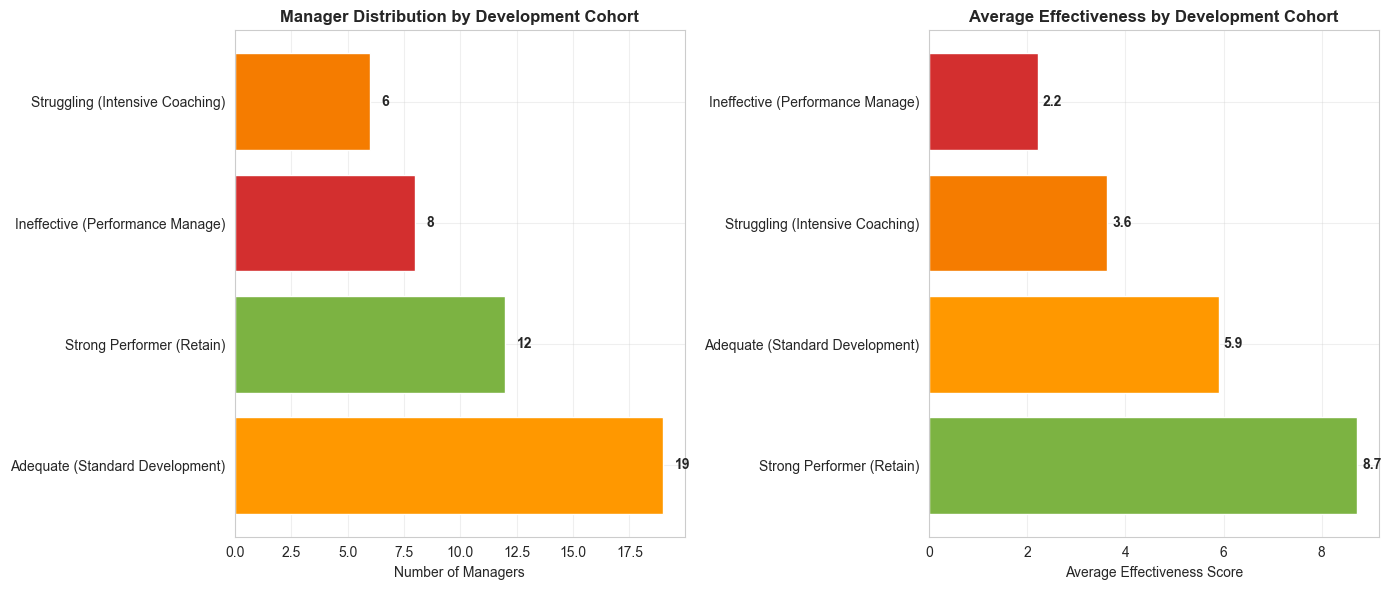

In [54]:
# Define development cohorts
def assign_cohort(row):
    if row['effectiveness_score'] >= 7.0 and row['promotion_rate'] >= 0.15:
        return 'High-Potential (Promote)'
    elif row['effectiveness_score'] >= 7.0:
        return 'Strong Performer (Retain)'
    elif row['effectiveness_score'] >= 5.0 and row['promotion_rate'] >= 0.10:
        return 'Emerging Leader (Develop)'
    elif row['effectiveness_score'] >= 5.0:
        return 'Adequate (Standard Development)'
    elif row['effectiveness_score'] >= 3.0:
        return 'Struggling (Intensive Coaching)'
    else:
        return 'Ineffective (Performance Manage)'

manager_potential['development_cohort'] = manager_potential.apply(assign_cohort, axis=1)

# Cohort summary
cohort_summary = manager_potential.groupby('development_cohort').agg({
    'manager_id': 'count',
    'effectiveness_score': 'mean',
    'avg_performance': 'mean',
    'promotion_rate': 'mean',
    'tenure_years': 'mean'
}).round(2)

cohort_summary.columns = ['Count', 'Avg Effectiveness', 'Avg Team Performance', 'Avg Promotion Rate', 'Avg Tenure']

print("\n=== MANAGER DEVELOPMENT COHORTS ===")
print(cohort_summary.to_string())

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Cohort Distribution
cohort_counts = manager_potential['development_cohort'].value_counts()
colors_map = {
    'High-Potential (Promote)': '#388e3c',
    'Strong Performer (Retain)': '#7cb342',
    'Emerging Leader (Develop)': '#fbc02d',
    'Adequate (Standard Development)': '#ff9800',
    'Struggling (Intensive Coaching)': '#f57c00',
    'Ineffective (Performance Manage)': '#d32f2f'
}
colors = [colors_map.get(x, 'gray') for x in cohort_counts.index]

axes[0].barh(range(len(cohort_counts)), cohort_counts.values, color=colors)
axes[0].set_yticks(range(len(cohort_counts)))
axes[0].set_yticklabels(cohort_counts.index)
axes[0].set_xlabel('Number of Managers')
axes[0].set_title('Manager Distribution by Development Cohort', fontweight='bold')
axes[0].grid(True, alpha=0.3)
for i, v in enumerate(cohort_counts.values):
    axes[0].text(v + 0.5, i, str(v), va='center', fontweight='bold')

# Plot 2: Effectiveness by Cohort
cohort_effectiveness = manager_potential.groupby('development_cohort')['effectiveness_score'].mean().sort_values(ascending=False)
colors2 = [colors_map.get(x, 'gray') for x in cohort_effectiveness.index]
axes[1].barh(range(len(cohort_effectiveness)), cohort_effectiveness.values, color=colors2)
axes[1].set_yticks(range(len(cohort_effectiveness)))
axes[1].set_yticklabels(cohort_effectiveness.index)
axes[1].set_xlabel('Average Effectiveness Score')
axes[1].set_title('Average Effectiveness by Development Cohort', fontweight='bold')
axes[1].grid(True, alpha=0.3)
for i, v in enumerate(cohort_effectiveness.values):
    axes[1].text(v + 0.1, i, f'{v:.1f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Recommended Actions by Cohort

Specific development recommendations for each cohort.

In [ ]:
print("\n" + "="*80)
print("MANAGER DEVELOPMENT RECOMMENDATIONS")
print("="*80)

recommendations = {
    'High-Potential (Promote)': [
        '✓ Identify promotion opportunities within 6-12 months',
        '✓ Assign stretch projects and cross-functional leadership roles',
        '✓ Provide executive coaching (1:1, NOT group training)',
        '✓ Include in succession planning for senior leadership',
        '⚠ DO NOT send to generic manager training (negative ROI for this group)'
    ],
    'Strong Performer (Retain)': [
        '✓ Recognize and reward excellent performance',
        '✓ Expand scope with additional responsibilities',
        '✓ Pair with struggling managers as mentors (peer learning)',
        '✓ Invite to share best practices via brown bags/workshops',
        '⚠ DO NOT send to generic manager training (negative ROI for this group)'
    ],
    'Emerging Leader (Develop)': [
        '✓ Pair with strong performer as mentor',
        '✓ Focus on specific skill gaps via 1:1 coaching',
        '✓ Provide quarterly check-ins and feedback',
        '✓ Job shadowing and stretch assignments',
        '⚠ Use targeted coaching, NOT broad training programs'
    ],
    'Adequate (Standard Development)': [
        '✓ Pair with strong performer as mentor',
        '✓ Set clear, specific performance improvement goals',
        '✓ Monitor progress quarterly',
        '✓ Focus on 1-2 specific skill gaps at a time',
        '⚠ Limited training budget - focus on targeted interventions only'
    ],
    'Struggling (Intensive Coaching)': [
        '✓✓ PRIORITY for training budget - positive ROI for this group',
        '✓✓ Enroll in intensive manager development program',
        '✓ Assign dedicated coach or mentor',
        '✓ Create 90-day improvement plan with clear metrics',
        '✓ Increase skip-level check-ins with their team',
        '✓ Consider span of control reduction if overextended',
        '✓ This is where training dollars have 2-3:1 ROI'
    ],
    'Ineffective (Performance Manage)': [
        '✓✓ PRIORITY for training budget if keeping in role',
        '✓✓ Intensive manager bootcamp as final intervention',
        '⚠ Initiate performance improvement plan with clear timeline',
        '⚠ Consider transition to individual contributor role',
        '⚠ Protect team members from poor management',
        '⚠ Make personnel decisions within 90 days if training doesn\'t work',
        '✓ If investing in training, this group shows positive ROI'
    ]
}

print("\n⚠ KEY PRINCIPLE: Training budget should be INVERTED")
print("   Traditional approach: Train high performers (WRONG - negative ROI)")
print("   Evidence-based approach: Train struggling managers (RIGHT - positive ROI)")

for cohort in cohort_counts.index:
    count = cohort_counts[cohort]
    print(f"\n{cohort} ({count} managers)")
    print("-" * 80)
    for rec in recommendations.get(cohort, []):
        print(f"  {rec}")

print("\n" + "="*80)

## Key Takeaways

1. **⚠ Training ROI depends on targeting**: Blanket training programs have negative/marginal ROI, but targeted training for struggling managers delivers 2-3:1 returns
2. **Struggling managers benefit most**: Highest ROI comes from developing ineffective and struggling managers - NOT general manager population
3. **Strategic budget allocation**: Focus training dollars on bottom 30% of managers; use mentoring/coaching for high performers instead
4. **High-potential managers identified**: Clear criteria for promotion and succession planning using 9-box methodology
5. **Development cohorts enable targeted investment**: Different cohorts need different interventions - one-size-fits-all is wasteful

**Recommended Next Steps**:
- **STOP** blanket manager training programs (negative ROI)
- **START** intensive coaching program specifically for struggling/ineffective managers
- Create promotion pipeline for identified high-potential managers
- Implement peer mentorship (not formal training) for adequate+ managers
- Establish quarterly manager effectiveness reviews with cohort-specific interventions
- Track segmented training ROI metrics over time